In [18]:
# 0. importing related libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score



In [2]:
# 1. loading data

df = pd.read_csv('Dataset_campus_wifi_Feature_Selected.csv')

# Separate features and target
X_selected = df.drop('Congestion_Encoded', axis=1).values
y = df['Congestion_Encoded'].values

print("X shape:", X_selected.shape)
print("y shape:", y.shape)
print("Any NaNs in X?", np.isnan(X_selected).any())
print("Class distribution:", pd.Series(y).value_counts())

X shape: (5509, 16)
y shape: (5509,)
Any NaNs in X? False
Class distribution: 1    5088
2     317
0     104
Name: count, dtype: int64


In [6]:
# 6.  Handle Class Imbalance

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_selected, y)

print("Before SMOTE:", pd.Series(y).value_counts())
print("After SMOTE:", pd.Series(y_resampled).value_counts())
# Now Low/Medium/High will be balanced

Before SMOTE: 1    5088
2     317
0     104
Name: count, dtype: int64
After SMOTE: 1    5088
2    5088
0    5088
Name: count, dtype: int64


In [8]:
# 7. Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

In [10]:
# 8. Model Trainer (Multiple Classifiers)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(kernel='rbf', probability=True),
    'KNN':                 KNeighborsClassifier(n_neighbors=5)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = model


Model: Logistic Regression | Accuracy: 0.5277
              precision    recall  f1-score   support

        High       0.45      0.33      0.38      1017
         Low       0.56      0.59      0.57      1018
      Medium       0.54      0.67      0.60      1018

    accuracy                           0.53      3053
   macro avg       0.52      0.53      0.52      3053
weighted avg       0.52      0.53      0.52      3053


Model: Decision Tree | Accuracy: 0.9011
              precision    recall  f1-score   support

        High       0.93      0.95      0.94      1017
         Low       0.89      0.85      0.87      1018
      Medium       0.89      0.90      0.90      1018

    accuracy                           0.90      3053
   macro avg       0.90      0.90      0.90      3053
weighted avg       0.90      0.90      0.90      3053


Model: Random Forest | Accuracy: 0.9555
              precision    recall  f1-score   support

        High       0.98      1.00      0.99      1017


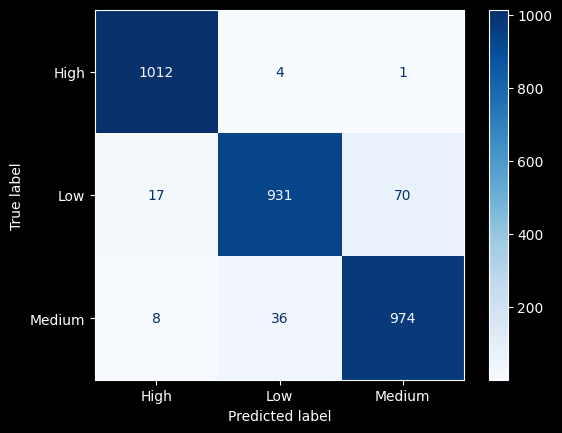

In [15]:
# 9. Evaluation

for name, model in results.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*40}")
    print(f"Model: {name} | Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred,
          target_names=['High', 'Low', 'Medium']))

# Confusion matrix for best model
best_model = results['Random Forest']
cm = confusion_matrix(y_test, best_model.predict(X_test))
disp = ConfusionMatrixDisplay(cm, display_labels=['High', 'Low', 'Medium'])
disp.plot(cmap='Blues')

print("Unique classes in y:", np.unique(y))


In [17]:
# 10. Hyperparameter Tuning (Best Model)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 0.9478340395245839


10-Fold CV Accuracy: 0.9598 ± 0.0086


(0.5, 1.0)

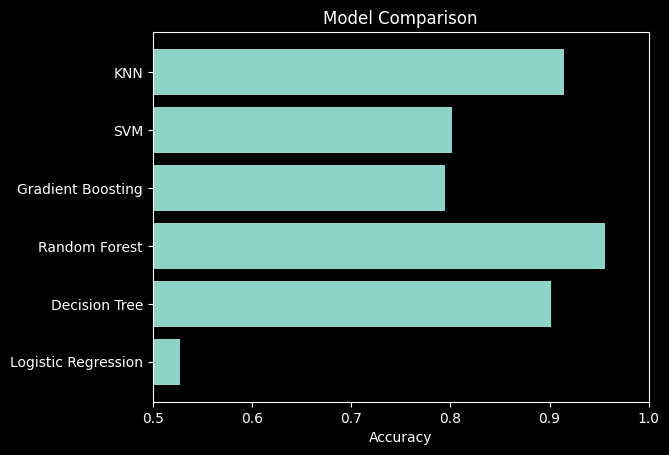

In [19]:
# 11. Cross-Validation & Final Reporting

cv_scores = cross_val_score(grid.best_estimator_, X_resampled, y_resampled, cv=10)
print(f"10-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Compare all models in a bar chart
import matplotlib.pyplot as plt
model_names = list(results.keys())
accuracies = [accuracy_score(y_test, m.predict(X_test)) for m in results.values()]
plt.barh(model_names, accuracies)
plt.xlabel('Accuracy')
plt.title('Model Comparison')
plt.xlim(0.5, 1.0)


In [22]:
# 12. Successful Saving of the Model.

import pickle
import os

# Create the models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Now save the model
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(grid.best_estimator_, f)

print("Model saved successfully!")

Model saved successfully!


In [23]:
# Continue to the WiFi_congestion_predictor.py file for the final result. The model evaluation part ends here.